<a href="https://colab.research.google.com/github/jaewoo0108/ml/blob/main/week06-softmax-neuralnetwork/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 6 - 신경망 설계와 활성화 함수들

- Linear, Sigmoid, ReLU, Softmax 활성화 함수
- 반올림오차(overflow) 안정화 방법(from_logits = True)



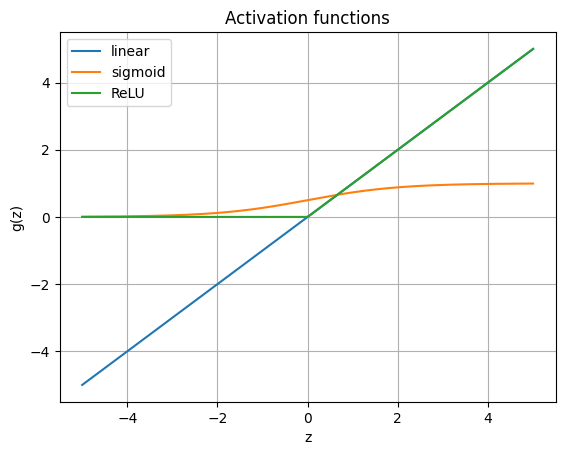

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def linear(z) : return z
def sigmoid(z) : return 1 / (1 + np.exp(-z))
def relu(z) : return np.maximum(0, z)

z = np.linspace(-5, 5, 200)
plt.plot(z, linear(z), label = "linear")
plt.plot(z, sigmoid(z), label = "sigmoid")
plt.plot(z, relu(z), label = "ReLU")
plt.title("Activation functions")
plt.xlabel("z")
plt.ylabel("g(z)")
plt.legend()
plt.grid(True)
plt.show()


## 출력층의 활성화 함수 - 예측하려는 정답(Y)이 무엇인지에 따라 결정


- 이진 분류 = sigmoid = 정답이 1일 확률 출력
- 다중 분류 = softmax = 정답이 특정 카테고리일 확률 출력
- (아무 실수값이나 가능한)회귀 = linear = 출력도 음수/양수값이 나와야하기에
- (양수값만 가능한) 회귀 = ReLU = 양수인 숫자만 출력하는 모델에 사용

## 은닉층의 활성화 함수 - 거의 항상 ReLU 사용

- max만 계산, 지수/역수 계산 없어서 연산이 가볍다
- ReLU 함수의 그래프에서 기울기가 0인(평평한) 구간이 음수일때 밖에 없기에, 비용함수의 지형도 덜 평평해지고 경사하강법의 속도 빠르다
- 양수쪽의 기울기가 1이기에 깊은 층까지 오차가 소실되지 않기에 기울기 소실문제 완화

In [ ]:
import tensorflow as tf
from sklearn.datasets import make_blobs

# 4개 클래스의 가짜 데이터 생성
# make_blobs : 중심점 주변에 점들을 뿌려주는 함수
X, y = make_blobs(n_samples = 300, centers = 4, n_features = 2, random_state = 0)

# 신경망 구조 정의

# 출력층의 뉴런 수는 분류하려고 하는 클래스 수와 같게 설정한다
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units = 15, activation = "relu"),
    tf.keras.layers.Dense(units = 4 , activation = "linear")
])
print(X.shape, "샘플 / 클래스 종류: ", np.unique(y))

(300, 2) 샘플 / 클래스 종류:  [0 1 2 3]


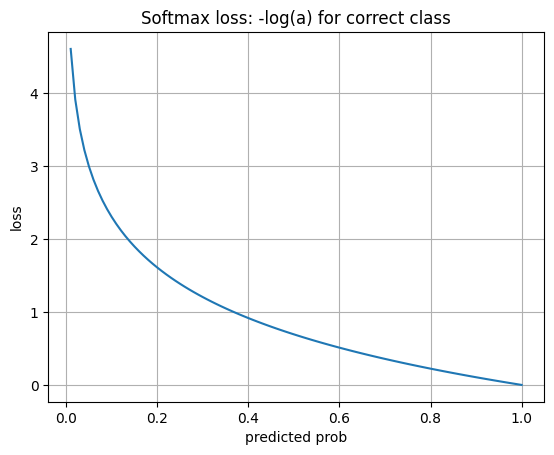

In [ ]:
# softmax의 loss 함수 : 정답 클래스 J에 대한 loss = -log(a_j)
# a_j가 1에 가까울수록 loss는 0에 가까워지고, 0에 가까워질수록 무한대로 커진다

a_correct = np.linspace(0.01, 1.0, 100)
loss = -np.log(a_correct)

plt.plot(a_correct, loss)
plt.title("Softmax loss: -log(a) for correct class")
plt.xlabel("predicted prob")
plt.ylabel("loss")
plt.grid(True)
plt.show()

In [ ]:
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam

# 다중 분류 문제이기때문에 softmax 활성화 함수와, SparseCategoricalCrossentropy 함수 사용
model.compile(loss = SparseCategoricalCrossentropy(from_logits= True),
              optimizer = Adam(0.01))

history = model.fit(X, y, epochs = 20)


Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1404  
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1323 
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1302 
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1252 
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1304 
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1273 
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1354 
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1320 
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1297 
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1288 
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1309 
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1258 
Epoch 13/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1245 
Epoch 14/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1265 
Epoch 15/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1325 
Epo

In [ ]:
# 모델 훈련 후, 데이터셋에서 5개 데이터를 예측한 결과
# 출력층의 활성화함수가 linear이기 때문에 확률이 아니라 logit값이 나온다
logits = model(X[:5])
print("logits =\n", logits)

predict_prob = tf.nn.softmax(logits).numpy()
print("\nProbabilities:\n", predict_prob)

print("\n각 행별 합:", predict_prob.sum(axis=1))


logits =
 tf.Tensor(
[[  1.3400537   -0.0593341    0.6720748   -8.718056  ]
 [ -0.15228742 -16.843832    -3.5231442    4.9616165 ]
 [  3.9266088   -7.860737    -4.900293    -2.2167468 ]
 [  1.0459872  -18.364202    -5.086759     6.441222  ]
 [  1.8564932    2.860183    -2.2344356  -14.114647  ]], shape=(5, 4), dtype=float32)

Probabilities:
 [[5.6833208e-01 1.4023478e-01 2.9140878e-01 2.4345618e-05]
 [5.9754020e-03 3.3676076e-10 2.0531604e-04 9.9381930e-01]
 [9.9770325e-01 7.5826692e-06 1.4639519e-04 2.1427725e-03]
 [4.5176079e-03 1.6794639e-11 9.8059772e-06 9.9547261e-01]
 [2.6701885e-01 7.2851562e-01 4.4655409e-03 3.0928838e-08]]

각 행별 합: [0.99999994 1.         1.         1.         1.        ]


In [ ]:
# softmax 함수 연산 따로, CategoricalCrossentropy함수 따로 계산하는 경우 z가 크면 e^z가 overflow

def my_softmax(z):
    return np.exp(z) / np.sum(np.exp(z))

# 보통 크기의 z -> 잘 동작한다
z_small = np.array([1.0, 2.0, 3.0])
print("작은 z : ", np.round(my_softmax(z_small), 4))

# z가 커지는 경우 e^z가 컴퓨터의 한계를 넘어 무한대가 되어버린다 -> nan
z_big = np.array([1000.0, 1001.0, 1002.0])
print("큰 z :", my_softmax(z_big))


작은 z :  [0.09   0.2447 0.6652]
큰 z : [nan nan nan]


/tmp/ipykernel_1865/2967209739.py:4: RuntimeWarning: overflow encountered in exp
  return np.exp(z) / np.sum(np.exp(z))
/tmp/ipykernel_1865/2967209739.py:4: RuntimeWarning: invalid value encountered in divide
  return np.exp(z) / np.sum(np.exp(z))


## 반올림 오차를 막는 방법 : from_logits = True

softmax 값을 따로 구해 손실함수에 넘기는 대신, softmax연산과 손실(-log) 계산을 하나로 합쳐 텐서플로우 내부적으로 수식 재배치해서 처리

--> 출력층의 활성화 함수를 'linear'로 설정
--> model.compile(loss = crossentropy(from_logits = True)) 설정

In [ ]:
# 활성화함수로 linear 함수를 사용하지 않는 이유
# linear함수를 사용하는 경우에 아무리 층을 여러개, 깊게 쌓아도 결국 하나의 거대한 linear 함수와 동일하기 때문에 의미가 없다

model = tf.keras.Sequential([
    tf.keras.layers.Dense(units = 1, activation = "linear"),
    tf.keras.layers.Dense(units = 1, activation = "linear")
])

x = np.array([1.0, 2.0])

a = model(x.reshape(2,-1))

w1,b1 = model.layers[0].get_weights()
w2,b2 = model.layers[1].get_weights()

b = (w1*x.reshape(2,-1)+b1) * w2 + b2

np.allclose(a,b)


True